# Library

In [105]:
from huggingface_hub import login
import json

with open('hf.json') as f:
    hf_data = json.load(f)

# Login menggunakan token Anda
login(token=hf_data["auth_token"])

In [106]:
import torch
from torch import nn
from torch.nn import functional as F
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd


# Data

In [107]:
train = pd.read_csv('/Users/muhammadnajmirahmani/ProjectNLP/penyisihan-ddsc25/train.csv')
test = pd.read_csv('/Users/muhammadnajmirahmani/ProjectNLP/penyisihan-ddsc25/test.csv')
train

,text,label
0,@hyalfay @NatharElyas @BosPurwa @NatharElyas @...,ideologi
1,@sienchao @Sherly0ctaviany @jokowi Halo @Sienc...,ideologi
2,@giovannikurnwn @BudiBukanIntel Nama Budi Berl...,ideologi
3,@LeotardosMy @easyanying Kita akui keberhasila...,ideologi
4,@LuckyGaben @susipudjiastuti @prabowo Indonesi...,ideologi
...,...,...
4995,Memang kristen zionis itu rata-rata IslamoPhob...,harmoni
4996,Masjid Lafadz Allah Dan wanita yang lekat deng...,harmoni
4997,@_MbakSri_ Mulut yang selalu jual toleransi ma...,harmoni
4998,@itsmesoya_ kalo masalah fisik dan lisan masi ...,pekerjaan


In [108]:
test

,id,text
0,0,@xuminghao_ogf @ShopeeID @ShopeePay_ID Bapak g...
1,1,tidak hanya membayangkan masa depan sebagai ki...
2,2,@feliscxtus Kalau aku jadi pemimpin RI visiku ...
3,3,@EkoDwiSant73293 @Dahnilanzar @prabowo Masyara...
4,4,@goonjol Mengamankan data pribadi rakyat RI si...
...,...,...
4995,4995,Cuma mau ngingetin den presiden @prabowo Sama ...
4996,4996,@BebySoSweet Bikin usaha aja selalu bubar ini ...
4997,4997,@BebySoSweet Sebenar nya @gibran_tweet ini uda...
4998,4998,@WongAlasRoban Bentuk pengusiran secara Halus....


# Text cleaning

In [109]:
import re
def clean_text(text):
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|pic\.twitter\.com\S+', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^A-Za-z\s]', '', text)
    # Split camel case words (e.g., "HelloWorld" -> "Hello World")
    text = re.sub(r'((?<=[a-z])[A-Z]|[A-Z](?=[a-z]))', r' \1', text)
    # Convert to lowercase
    text = text.lower()
    # Remove repetitive characters (e.g., "soooo" -> "so") if it occurs more than 3 times
    text = re.sub(r'(.)\1{3,}', r'\1', text)
    # Hapus kata rt
    text = re.sub(r'\brt\b', '', text)
    # Hapus satu huruf
    text = re.sub(r'\b[a-zA-Z]\b', '', text)
    # Normalisasi spasi
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove emojis
    text = re.sub(r'[^\w\s,]', '', text)
    # Remove angka
    text = re.sub(r'\d+', '', text)

    return text.strip()

train['cleaned_text'] = train['text'].apply(clean_text)
test['cleaned_text'] = test['text'].apply(clean_text)
train[['text', 'cleaned_text']]

,text,cleaned_text
0,@hyalfay @NatharElyas @BosPurwa @NatharElyas @...,prabowo menang di karena strategi cerdas media...
1,@sienchao @Sherly0ctaviany @jokowi Halo @Sienc...,halo mungkin terus mengangkat isu negatif joko...
2,@giovannikurnwn @BudiBukanIntel Nama Budi Berl...,nama budi berlar mungkin mencerminkan sikap kr...
3,@LeotardosMy @easyanying Kita akui keberhasila...,kita akui keberhasilannya kita akui juga kekur...
4,@LuckyGaben @susipudjiastuti @prabowo Indonesi...,indonesia masih bisa menuju kesuksesan tapi ru...
...,...,...
4995,Memang kristen zionis itu rata-rata IslamoPhob...,memang kristen zionis itu ratarata islamo phob...
4996,Masjid Lafadz Allah Dan wanita yang lekat deng...,masjid lafadz allah dan wanita yang lekat deng...
4997,@_MbakSri_ Mulut yang selalu jual toleransi ma...,mulut yang selalu jual toleransi malah dia sen...
4998,@itsmesoya_ kalo masalah fisik dan lisan masi ...,kalo masalah fisik dan lisan masi bisa di tole...


# EDA

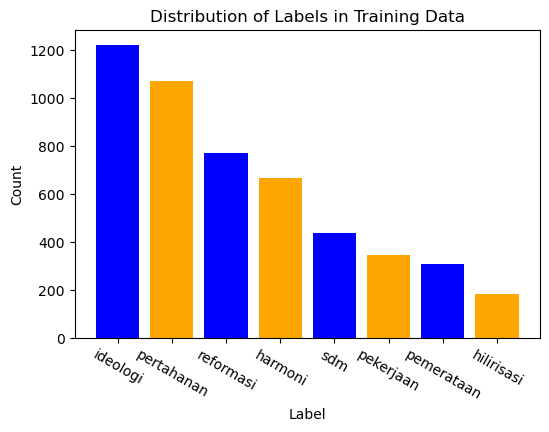

In [110]:
# Distribution of labels
label_counts = train['label'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values, color=['blue', 'orange'])
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Labels in Training Data')
plt.xticks(rotation=-30)
plt.show()

In [111]:
# Check missing values
def check_missing_values(df):
    missing_values = df.isnull().sum()
    print("Missing values in each column:")
    print(missing_values)

check_missing_values(train)
check_missing_values(test)

Missing values in each column:
text            0
label           0
cleaned_text    0
dtype: int64
Missing values in each column:
id              0
text            0
cleaned_text    0
dtype: int64


In [112]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   text          5000 non-null   object
 1   label         5000 non-null   object
 2   cleaned_text  5000 non-null   object
dtypes: object(3)
memory usage: 117.3+ KB


In [113]:
# Check duplicate entries
def check_duplicates(df, subset=None):
    duplicate_count = df.duplicated(subset=subset, keep=False).sum()
    print(f"Number of duplicate entries: {duplicate_count}")

check_duplicates(train, subset=['cleaned_text'])
check_duplicates(test, subset=['cleaned_text'])

Number of duplicate entries: 6
Number of duplicate entries: 2


In [114]:
# Drop duplicates if any
train = train.drop_duplicates(subset=['text'], keep='first')

In [115]:
lexicon = pd.read_csv('archive/colloquial-indonesian-lexicon.csv')
drop_words = pd.read_excel('corpus.xlsx', 'Drop')
slang = pd.read_excel('corpus.xlsx', 'Kamus')

In [116]:
lexicon

,slang,formal,In-dictionary,context,category1,category2,category3
0,woww,wow,1,wow,elongasi,0,0
1,aminn,amin,1,Selamat ulang tahun kakak tulus semoga panjang...,elongasi,0,0
2,met,selamat,1,Met hari netaas kak!? Wish you all the best @t...,abreviasi,0,0
3,netaas,menetas,1,Met hari netaas kak!? Wish you all the best @t...,afiksasi,elongasi,0
4,keberpa,keberapa,0,Birthday yg keberpa kak?,abreviasi,0,0
...,...,...,...,...,...,...,...
15001,gataunya,enggak taunya,0,Ini kaya nenek2 ya beb gataunya agnezz @yugime...,akronim,0,0
15002,gtau,enggak tau,0,Stidaknya mrka may berkarya Dan berusaha yg tr...,akronim,abreviasi,0
15003,gatau,enggak tau,0,Ih gatau malu,akronim,0,0
15004,fans2,fan-fan,0,Jkt48 adalah tempat di mana sesama fans saling...,reduplikasi,naturalisasi,0


In [117]:
# Make a clean text buat EDA nantinya, biar lebih mudah buat wordcloud atau analisis lainnya.

# Normalisasi kata
def normalisasi(token):
  for i in range(len(token)):
    if token[i] in lexicon['slang'].values:
      idx = lexicon.index[lexicon['slang'] == token[i]][0]
      token[i] = lexicon['formal'][idx]

    if token[i] in slang['kata'].values:
      idx = slang.index[slang['kata'] == token[i]][0]
      token[i] = slang['pengganti'][idx]
  return token

# Membuat kamus untuk token yang akan di-drop
drop_tokens = set(drop_words['drop'])

# Menghapus token yang ada di kamus drop_df
def remove_drop_tokens(tokens):
    return [token for token in tokens if token not in drop_tokens]

# Normalisasi
train['normalized_text'] = train['cleaned_text'].apply(lambda x: normalisasi(x.split()))
train['normalized_text'] = train['normalized_text'].apply(lambda x: ' '.join(x))
test['normalized_text'] = test['cleaned_text'].apply(lambda x: normalisasi(x.split()))
test['normalized_text'] = test['normalized_text'].apply(lambda x: ' '.join(x))

/var/folders/qj/g9zb81ls0mvf1zn_4mb17x9h0000gn/T/ipykernel_30841/4222334707.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['normalized_text'] = train['cleaned_text'].apply(lambda x: normalisasi(x.split()))
/var/folders/qj/g9zb81ls0mvf1zn_4mb17x9h0000gn/T/ipykernel_30841/4222334707.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['normalized_text'] = train['normalized_text'].apply(lambda x: ' '.join(x))


In [118]:
train[['cleaned_text', 'normalized_text']]

,cleaned_text,normalized_text
0,prabowo menang di karena strategi cerdas media...,prabowo menang di karena strategi cerdas media...
1,halo mungkin terus mengangkat isu negatif joko...,halo mungkin terus mengangkat isu negatif joko...
2,nama budi berlar mungkin mencerminkan sikap kr...,nama budi berlar mungkin mencerminkan sikap kr...
3,kita akui keberhasilannya kita akui juga kekur...,kita akui keberhasilannya kita akui juga kekur...
4,indonesia masih bisa menuju kesuksesan tapi ru...,indonesia masih bisa menuju kesuksesan tapi ru...
...,...,...
4995,memang kristen zionis itu ratarata islamo phob...,memang kristen zionis itu ratarata islamo phob...
4996,masjid lafadz allah dan wanita yang lekat deng...,masjid lafadz allah dan wanita yang lekat deng...
4997,mulut yang selalu jual toleransi malah dia sen...,mulut yang selalu jual toleransi malah dia sen...
4998,kalo masalah fisik dan lisan masi bisa di tole...,kalo masalah fisik dan lisan masih bisa di tol...


In [119]:
# Stopword removal
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()
train['final_text'] = train['normalized_text'].apply(stopword_remover.remove)
test['final_text'] = test['normalized_text'].apply(stopword_remover.remove)

import nltk
nltk.download('punkt')
nltk.download('stopwords')

stopword_eng = set(nltk.corpus.stopwords.words('english'))
train['final_text'] = train['final_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stopword_eng]))
test['final_text'] = test['final_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stopword_eng]))

train[['cleaned_text', 'normalized_text', 'final_text']]

/var/folders/qj/g9zb81ls0mvf1zn_4mb17x9h0000gn/T/ipykernel_30841/668329506.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['final_text'] = train['normalized_text'].apply(stopword_remover.remove)
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/muhammadnajmirahmani/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/muhammadnajmirahmani/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/qj/g9zb81ls0mvf1zn_4mb17x9h0000gn/T/ipykernel_30841/668329506.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

,cleaned_text,normalized_text,final_text
0,prabowo menang di karena strategi cerdas media...,prabowo menang di karena strategi cerdas media...,prabowo menang karena strategi cerdas media so...
1,halo mungkin terus mengangkat isu negatif joko...,halo mungkin terus mengangkat isu negatif joko...,halo mungkin terus mengangkat isu negatif joko...
2,nama budi berlar mungkin mencerminkan sikap kr...,nama budi berlar mungkin mencerminkan sikap kr...,nama budi berlar mungkin mencerminkan sikap kr...
3,kita akui keberhasilannya kita akui juga kekur...,kita akui keberhasilannya kita akui juga kekur...,akui keberhasilannya akui kekurangan gue terla...
4,indonesia masih bisa menuju kesuksesan tapi ru...,indonesia masih bisa menuju kesuksesan tapi ru...,indonesia menuju kesuksesan ruu tni dwifungsi ...
...,...,...,...
4995,memang kristen zionis itu ratarata islamo phob...,memang kristen zionis itu ratarata islamo phob...,memang kristen zionis ratarata islamo phobia a...
4996,masjid lafadz allah dan wanita yang lekat deng...,masjid lafadz allah dan wanita yang lekat deng...,masjid lafadz allah wanita lekat masjid lafadz...
4997,mulut yang selalu jual toleransi malah dia sen...,mulut yang selalu jual toleransi malah dia sen...,mulut selalu jual toleransi malah sendiri menj...
4998,kalo masalah fisik dan lisan masi bisa di tole...,kalo masalah fisik dan lisan masih bisa di tol...,kalo masalah fisik lisan bisa toleransi kalo d...


Word Cloud for Label ideologi:


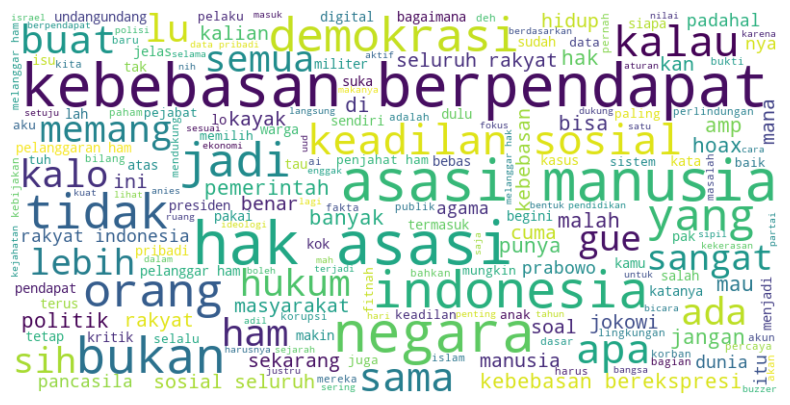

Word Cloud for Label pertahanan:


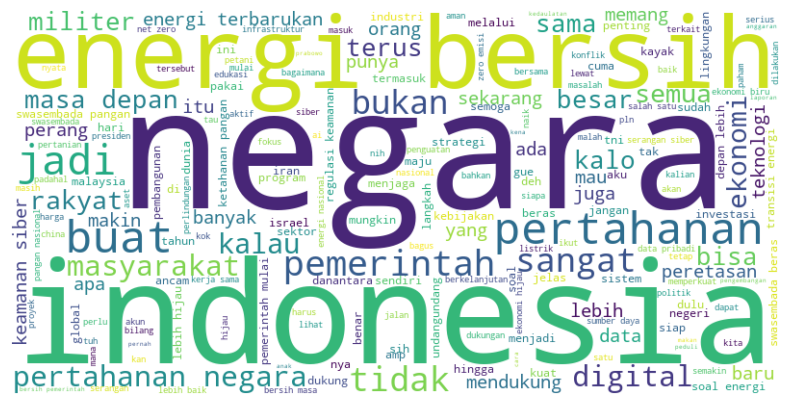

Word Cloud for Label pekerjaan:


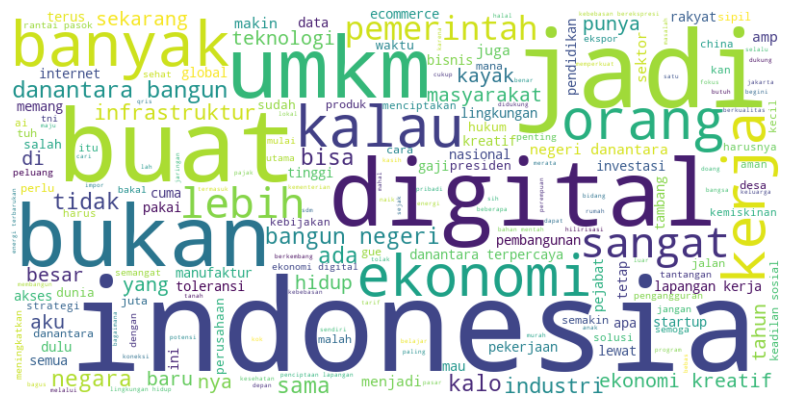

Word Cloud for Label sdm:


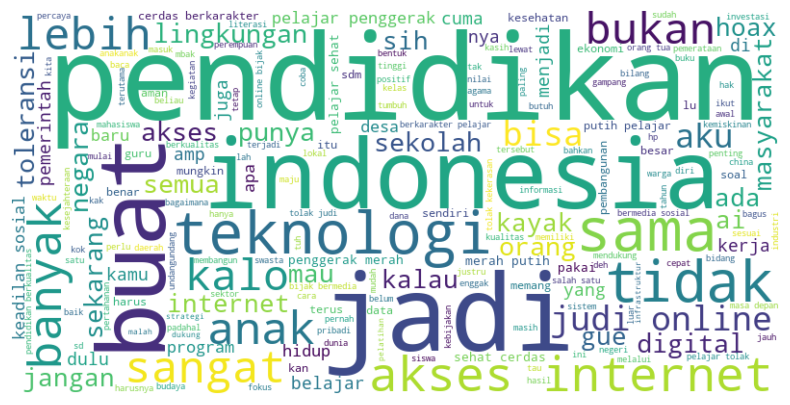

Word Cloud for Label hilirisasi:


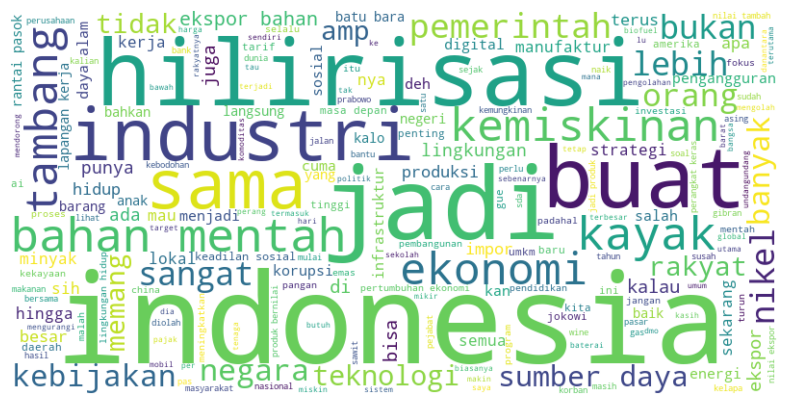

Word Cloud for Label pemerataan:


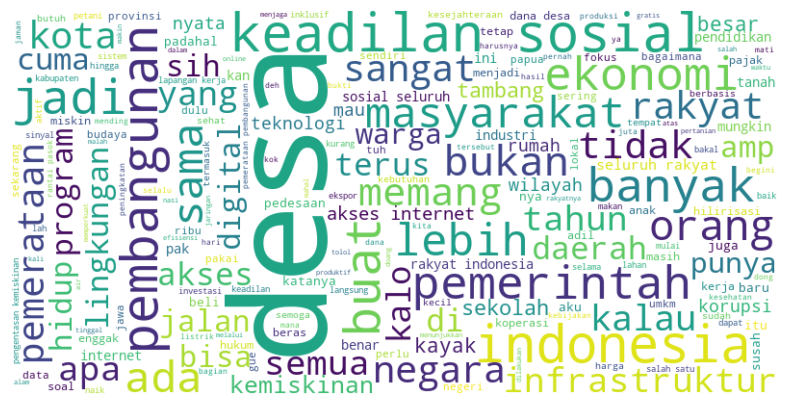

Word Cloud for Label reformasi:


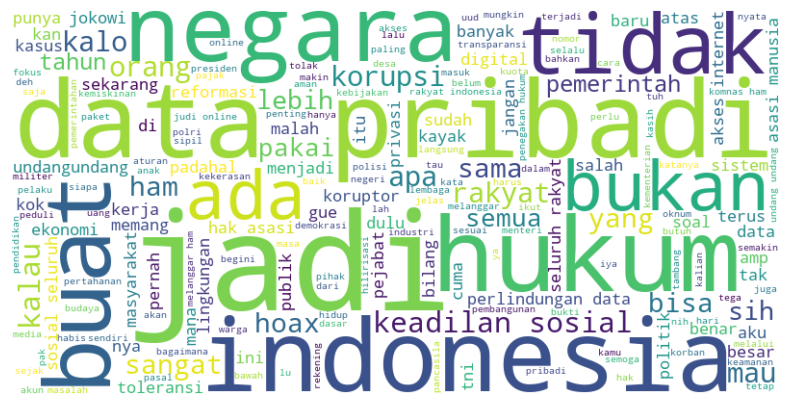

Word Cloud for Label harmoni:


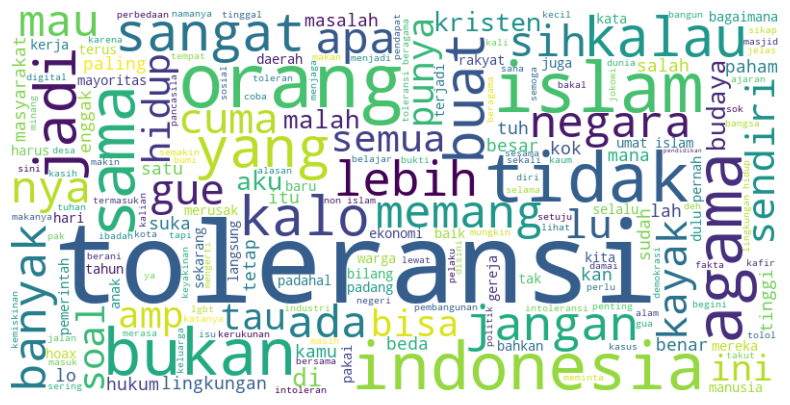

In [120]:
def generate_wordcloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

for label in train['label'].unique():
    text = ' '.join(train[train['label'] == label]['final_text'])
    print(f"Word Cloud for Label {label}:")
    generate_wordcloud(text)

In [121]:
train[['cleaned_text', 'normalized_text', 'label']].to_csv('train_cleaned.csv', index=False)
test[['cleaned_text', 'normalized_text']].to_csv('test_cleaned.csv', index=False)

# Modelling

In [122]:
train = pd.read_csv('train_cleaned.csv')
test = pd.read_csv('test_cleaned.csv')

In [123]:
from transformers import BertTokenizer, AutoModel
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
model = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")


The following layers were not sharded: embeddings.word_embeddings.weight, encoder.layer.*.attention.output.dense.bias, encoder.layer.*.output.LayerNorm.weight, encoder.layer.*.intermediate.dense.weight, encoder.layer.*.attention.self.query.bias, encoder.layer.*.attention.self.query.weight, encoder.layer.*.output.LayerNorm.bias, embeddings.LayerNorm.bias, encoder.layer.*.attention.self.key.weight, encoder.layer.*.attention.self.value.weight, embeddings.token_type_embeddings.weight, encoder.layer.*.intermediate.dense.bias, encoder.layer.*.attention.self.value.bias, encoder.layer.*.attention.output.LayerNorm.bias, encoder.layer.*.attention.output.dense.weight, encoder.layer.*.output.dense.weight, encoder.layer.*.attention.output.LayerNorm.weight, pooler.dense.bias, encoder.layer.*.attention.self.key.bias, encoder.layer.*.output.dense.bias, embeddings.LayerNorm.weight, embeddings.position_embeddings.weight, pooler.dense.weight


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [124]:
x = torch.LongTensor(tokenizer.encode('aku adalah anak [MASK]')).view(1,-1)
print(x, model(x)[0].sum())


tensor([[  2, 304, 154, 436,   4,   3]]) tensor(0.6092, grad_fn=<SumBackward0>)


# Split Data

In [125]:
from transformers import BertForSequenceClassification

num_classes = len(train['label'].unique())
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train['label_encoded'] = le.fit_transform(train['label'])

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(train['cleaned_text'], train['label_encoded'], test_size=0.2, random_state=42)

# Augment Data

In [126]:
import nlpaug.augmenter.word as naw
from transformers import PreTrainedTokenizerBase
PreTrainedTokenizerBase._convert_token_to_id = PreTrainedTokenizerBase.convert_tokens_to_ids

aug = naw.ContextualWordEmbsAug(
    model_path='indobenchmark/indobert-base-p1', 
    action="substitute",
    device='cpu',
    top_k=5,
    aug_p=0.3 
)

def augment_text(text):
    return aug.augment(text)

augmented_text = []
augment_labels = []

for text, label in zip(X_train, y_train):
    augmented = aug.augment(text)
    augment_text = augmented[0] if isinstance(augmented, list) else augmented
    augmented_text.append(augment_text)
    augment_labels.append(label)

train_texts = list(X_train) + augmented_text
train_labels = list(y_train) + augment_labels

In [127]:
train_augmented = pd.DataFrame({'text': train_texts, 'label': train_labels})
train_augmented.to_csv('train_augmented2.csv', index=False)

# Resampling

In [128]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42, sampling_strategy='auto')

X_resampled, y_resampled = ros.fit_resample(np.array(train_texts).reshape(-1, 1), train_labels)
X_resampled = X_resampled.flatten()
X_resampled[:10], y_resampled[:10]

(array(['dalam negara yang mengaku demokratis dan konstitusional pengangguran bukan hanya statistik ekonomi melainkan indikator keadilan sosial ketika negara diam maka itu bukan hanya lepas tangan tetapi lepas tanggung jawab konstitusional',
        'kebebasan berpendapat adalah hak setiap orang utk menyampaikan pikiran dan pandangannya baik secara lisan maupun tulisan termasuk menyatakan dukungannya pada israel ini dijamin dalam uud jangan menjadi munafik',
        'ngabrut bgt tiba intv pas ditanya mimpi jawabnya membahagiakan orangtua',
        'bahkan toleransi sering dijual sebagai isu sehingga tak jarang ada pihak yg diuntungkan kita setara sebagai warga negara tdk ada mayoritasminoritas setara hidup berdampingan amp',
        'sekarang era teknologi internet gratis bisa masuk ke pelosok negeri untuk menjangkau pendidikan teknologi pangan dan ekonomi digital itu lebih bagus ketimbang mbg tapi malah meracuni siswa',
        'prinsip kopdes menurut pemikiran para tokoh pentingnya p

In [129]:
pd.Series(y_resampled).value_counts()

3    1972
2    1972
7    1972
0    1972
4    1972
5    1972
6    1972
1    1972
Name: count, dtype: int64

In [130]:
train_resampled = pd.DataFrame({'text': X_resampled, 'label': y_resampled})
train_resampled.to_csv('train_resampled.csv', index=False)

# Training

In [131]:
train = pd.read_csv('train_resampled.csv')
X_train = train['text']
y_train = train['label']

In [132]:
# Panjang teks rata-rata setelah augmentasi
avg_length = X_train.apply(lambda x: len(x.split())).mean()
print(f"Average text length after augmentation: {avg_length:.2f} words")

# Max length teks setelah augmentasi
max_length = X_train.apply(lambda x: len(x.split())).max()
print(f"Max text length after augmentation: {max_length} words")

Average text length after augmentation: 28.70 words
Max text length after augmentation: 56 words


In [133]:
label2id = {label: idx for idx, label in enumerate(le.classes_)}
id2label = {idx: label for label, idx in label2id.items()}


#indolem/indotweet-roberta-base
#indobenchmark/indobert-base-p1
# 1. Load model klasifikasi bawaan
classifier = BertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1", 
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

# 2. Freeze parameters BERT (opsional, persis seperti niat Anda)
for param in classifier.bert.parameters():
    param.requires_grad = False

print(classifier)

You passed `num_labels=8` which is incompatible to the `id2label` map of length `5`.
The following layers were not sharded: bert.encoder.layer.*.intermediate.dense.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.self.key.bias, bert.embeddings.position_embeddings.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.embeddings.LayerNorm.bias, bert.embeddings.LayerNorm.weight, bert.encoder.layer.*.attention.self.value.weight, bert.encoder.layer.*.output.dense.weight, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.attention.output.dense.bias, bert.pooler.dense.bias, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.query.weight, bert.embeddings.word_embeddings.weight, bert.encoder.layer.*.output.LayerNorm.bias, bert.pooler.dense.weight, bert.encoder.lay

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [134]:
from transformers import TrainingArguments, IntervalStrategy

training_args = TrainingArguments(
    output_dir="./results",           
    eval_strategy=IntervalStrategy.EPOCH,     
    save_strategy="epoch",           
    
    learning_rate=1e-3,              
    
    per_device_train_batch_size=32,  
    per_device_eval_batch_size=64,   
    
    num_train_epochs=15,              
    
    
    weight_decay=0.01,               
    
    save_total_limit=2,              
    load_best_model_at_end=True,     
    metric_for_best_model='balanced_accuracy',
    greater_is_better=True,
    
    
    logging_dir="./logs",            
    logging_steps=100,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine'
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [135]:
import torch
import numpy as np
from transformers import Trainer, BertTokenizerFast
from evaluate import load
from torch.utils.data import Dataset
from sklearn.metrics import balanced_accuracy_score

# 1. Definisi CustomDataset
class CustomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Mengubah data dari list menjadi format dictionary berisi PyTorch tensors
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Menambahkan label
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# 2. Definisi compute_metrics
metric = load("accuracy")

from evaluate import load
import numpy as np

# Load dua metrik sekaligus
metric_acc = load("accuracy")
metric_f1 = load("f1")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    # Hitung akurasi
    acc = metric_acc.compute(predictions=predictions, references=labels)
    
    # Hitung F1-Macro (Sangat penting untuk data imbalanced)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="macro")

    # Hitung Balanced Accuracy
    balanced_acc = balanced_accuracy_score(labels, predictions)
    
    # Gabungkan hasil
    return {
        "accuracy": acc["accuracy"],
        "f1_macro": f1["f1"],
        "balanced_accuracy": balanced_acc
    }

# 3. Inisialisasi Tokenizer
tokenizer = BertTokenizerFast.from_pretrained("indobenchmark/indobert-base-p1")

# HAPUS return_tensors="pt" karena conversion akan dilakukan oleh CustomDataset
X_train_tokenized = tokenizer(X_train.tolist(), padding=True, max_length=64, truncation=True)
X_val_tokenized = tokenizer(X_val.tolist(), padding=True, max_length=64, truncation=True)

# 4. Inisialisasi Dataset
train_dataset = CustomDataset(X_train_tokenized, y_train.tolist())
val_dataset = CustomDataset(X_val_tokenized, y_val.tolist())


from sklearn.utils.class_weight import compute_class_weight
import torch
from torch import nn

# Hitung rasio bobot yang adil secara otomatis
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# Pindahkan tensor ke GPU/MPS (Sangat penting agar tidak error di Mac)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = class_weights_tensor.to(device)

print("Bobot Kelas:", class_weights) 

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Gunakan CrossEntropyLoss dengan bobot (weights)
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

# Gunakan CustomTrainer (bukan Trainer biasa)
trainer = CustomTrainer(
    model=classifier,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics  # Pastikan sudah pakai f1-macro
)

# trainer.train()
# # 5. Inisialisasi Trainer & Mulai Training
# # (Pastikan variabel 'classifier' dan 'training_args' sudah di-run di cell sebelumnya)
# trainer = Trainer(
#     model=classifier,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     compute_metrics=compute_metrics
# )

trainer.train()

Bobot Kelas: [1. 1. 1. 1. 1. 1. 1. 1.]


/opt/homebrew/Caskroom/miniconda/base/envs/ml_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Balanced Accuracy
1,1.920114,1.810079,0.324000,0.279503,0.314366
2,1.676628,1.587074,0.469000,0.420019,0.430724
3,1.621056,1.507529,0.503000,0.446557,0.459402
4,1.572766,1.481504,0.533000,0.469882,0.478368
5,1.508056,1.505536,0.510000,0.443705,0.452955
6,1.521883,1.495432,0.528000,0.462297,0.478938
7,1.495055,1.472478,0.542000,0.480033,0.495848
8,1.472849,1.478880,0.535000,0.479337,0.493948
9,1.505096,1.438873,0.561000,0.497917,0.507241
10,1.471881,1.408193,0.561000,0.491167,0.496455


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniconda/base/envs/ml_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniconda/base/envs/ml_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=7395, training_loss=1.5482257133726336, metrics={'train_runtime': 1214.707, 'train_samples_per_second': 194.812, 'train_steps_per_second': 6.088, 'total_flos': 7783244290621440.0, 'train_loss': 1.5482257133726336, 'epoch': 15.0})

In [136]:
# import torch
# import numpy as np
# from transformers import AutoTokenizer, AutoModel
# from xgboost import XGBClassifier
# from sklearn.metrics import classification_report, f1_score

# # 1. Load Model BERT Dasar (Bukan model klasifikasi)
# # Gunakan indobert-base-p1 karena tadi performanya lebih baik dari indotweet
# tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
# model_base = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")

# # Pindahkan model ke device yang tersedia (MPS/CUDA/CPU)
# device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
# model_base = model_base.to(device)
# model_base.eval() # Matikan mode training pada BERT

# # 2. Fungsi untuk mengubah teks menjadi Vektor Angka (Embeddings)
# def get_bert_embeddings(texts, batch_size=32):
#     all_embeddings = []
    
#     for i in range(0, len(texts), batch_size):
#         batch_texts = texts[i:i+batch_size]
#         # Tokenisasi
#         encoded = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors='pt')
#         encoded = {key: val.to(device) for key, val in encoded.items()}
        
#         with torch.no_grad():
#             outputs = model_base(**encoded)
#             # Ambil representasi token [CLS] yang ada di indeks 0
#             cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
#             all_embeddings.extend(cls_embeddings)
            
#     return np.array(all_embeddings)

# # 3. Ekstrak fitur (Proses ini mungkin memakan waktu beberapa menit)
# print("Mengekstrak fitur untuk Data Train...")
# X_train_bert = get_bert_embeddings(X_train.tolist())

# print("Mengekstrak fitur untuk Data Validation...")
# X_val_bert = get_bert_embeddings(X_val.tolist())

# # 4. Latih menggunakan XGBoost
# print("Melatih XGBoost...")
# xgb_model = XGBClassifier(
#     n_estimators=200,
#     learning_rate=0.1,
#     max_depth=5,
#     random_state=42,
#     # Jika XGBoost versi baru, tambahkan parameter ini untuk data imbalanced kelas banyak
#     objective='multi:softmax', 
#     num_class=len(np.unique(y_train))
# )

# # y_train pastikan sudah berupa label encoded (0, 1, 2...)
# xgb_model.fit(X_train_bert, y_train.tolist())

# # 5. Evaluasi
# y_pred = xgb_model.predict(X_val_bert)

# print("\n--- HASIL HYBRID (BERT + XGBoost) ---")
# print("F1-Macro:", f1_score(y_val.tolist(), y_pred, average='macro'))
# print("\nClassification Report:\n", classification_report(y_val.tolist(), y_pred))

In [137]:
# X_test_bert = get_bert_embeddings(test['normalized_text'].tolist())

# # Prediksi di test set
# test_predictions = xgb_model.predict(X_test_bert)
# test['predicted_label'] = le.inverse_transform(test_predictions)
# test[['normalized_text', 'predicted_label']]

# Prediction

In [138]:
# Predict di test set
X_test_tokenized = tokenizer(test['normalized_text'].tolist(), padding=True, max_length=64, truncation=True)
test_dataset = CustomDataset(X_test_tokenized, [0]*len(test))  # Label dummy karena kita hanya ingin prediksi
predictions = trainer.predict(test_dataset)
predicted_labels = np.argmax(predictions.predictions, axis=-1)
test['predicted_label'] = le.inverse_transform(predicted_labels)
test[['normalized_text', 'predicted_label']]

/opt/homebrew/Caskroom/miniconda/base/envs/ml_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/opt/homebrew/Caskroom/miniconda/base/envs/ml_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,normalized_text,predicted_label
0,bapak gua juga begini bedanya dia bahkan engga...,reformasi
1,tidak hanya membayangkan masa depan sebagai ki...,sdm
2,kalau aku jadi pemimpin ri visiku buat indones...,sdm
3,masyarakat bisa menerapkan strategi seperti be...,pekerjaan
4,mengamankan data pribadi rakyat ri sik durung ...,reformasi
...,...,...
4995,cuma mau mengingatkan den presiden sama kil de...,ideologi
4996,buat usaha saja selalu bubar ini pakai janji b...,reformasi
4997,sebenar nya ini sudah banyak buka lapangan pek...,hilirisasi
4998,bentuk pengusiran secara halus atau memang kib...,sdm


In [139]:
submission = pd.read_csv('/Users/muhammadnajmirahmani/ProjectNLP/penyisihan-ddsc25/sample_submission.csv')
submission['label'] = test['predicted_label']
submission.to_csv('submission.csv', index=False)